# 1.背景：顧客特性を予測して解約を防ぐ
競争の激しい通信業界において、顧客の解約（チャーン）は企業の収益に直接的な影響を与える重要な要素です。  
本プロジェクトでは、データ分析と機械学習モデルを活用して解約しやすい顧客の特性を予測し、企業がより効果的な顧客維持（リテンション）戦略を立てられるよう支援することを目的としています。  

<b>顧客解約を予測することの意義</b>
1. **マーケティングコストの削減**  
　新規顧客の獲得コストは、既存顧客の維持コストの約5倍と言われています。  
　離脱の可能性が高い顧客を事前に特定することで、効果的な対策を講じ、無駄なコストを削減することができます。  
2. **ユーザー体験の向上**  
　すべての付加価値サービスが顧客満足度を高めるとは限りません。  
　顧客の行動データを分析することで、より的確にニーズを把握し、価値あるサービスを提供できます。  
3. **売上および投資収益率の向上**  
　価格に敏感な顧客とそうでない顧客を識別することで、価格戦略やマーケティング戦略を差別化し、より高いリターンを得ることができます。  

# 2.問題を提出
1. 解約（チャーン）した顧客には、どのような顕著な特徴（購買行動）があるのか？  
2. これらの顧客に対して、どのような施策を講じることで解約を防止できるのか？

# 3.データセットの説明

本データは **Kaggle** より取得したもので、以下のリンクから入手可能です：  
[Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

このデータセットは、**21個の変数**と**7,043件の顧客データ**で構成されています。  
<font color='red'>**変数は大きく分けて、次の3つのカテゴリに分類されます**</font>

##### 1. 顧客属性（User Attributes）
| 変数名 | 説明 |
|--------|------|
| `customerID` | 顧客ID |
| `gender` | 性別（Female / Male） |
| `SeniorCitizen` | 高齢者かどうか（1：Yes、0：No） |
| `Partner` | 配偶者の有無（Yes / No） |
| `Dependents` | 扶養家族の有無（Yes / No） |
| `tenure` | 契約期間（0〜72ヶ月） |

##### 2. 顧客行動（User Behavior）

| 変数名 | 説明 |
|--------|------|
| `PhoneService` | 電話サービスの契約有無（Yes / No） |
| `MultipleLines` | 複数回線の契約有無（Yes / No / No phone service） |
| `InternetService` | インターネットサービスの種類（No / DSL / Fiber optic） |
| `OnlineSecurity` | オンラインセキュリティサービスの契約有無（Yes / No / No internet service） |
| `OnlineBackup` | オンラインバックアップサービスの契約有無（Yes / No / No internet service） |
| `DeviceProtection` | デバイス保護サービスの契約有無（Yes / No / No internet service） |
| `TechSupport` | テクニカルサポートの契約有無（Yes / No / No internet service） |
| `StreamingTV` | ストリーミングTVの契約有無（Yes / No / No internet service） |
| `StreamingMovies` | ストリーミング映画の契約有無（Yes / No / No internet service） |
| `Contract` | 契約タイプ（Month-to-month / One year / Two year） |
| `PaperlessBilling` | ペーパーレス請求の利用有無（Yes / No） |
| `PaymentMethod` | 支払い方法（Bank transfer / Credit card / Electronic check / Mailed check） |
| `MonthlyCharges` | 月額料金 |
| `TotalCharges` | 総料金 |

##### 3. 目的変数（Target Variable）

| 変数名 | 説明 |
|--------|------|
| `Churn` | 顧客が解約したかどうか（Yes / No） |

# 4. 分析の考え方

上で提出した問題に基づき、以下の2点を解決することを目指す：
1. 問題1：解約（チャーン）した顧客には、どのような顕著な特徴（購買行動）があるのか？ 
2. 問題2：これらの顧客に対して、どのような施策を講じることで解約を防止できるのか？

また、前述のデータセットに基づき、データは以下の3カテゴリに分類されていた：  
- ユーザー属性  
- ユーザー行動  
- 解約有無
---

#### 問題1：解約顧客の特徴を探索


分析方法は以下の通り：<br> 
<font color='red'>**1.伝統的な統計分析により各特徴を比較し、解約しやすい顧客の特徴を特定する**</font> 
  - 数値型データ  → 平均値を比較  
  - カテゴリ型データ  → 頻度を比較

> <font color='blue'>注意：複数の条件で解約リスクの高い顧客を絞り込む場合、条件を増やすほどターゲット顧客はより明確になるが、対象人数も減少する。そのため、各特徴の重要性を評価し、最も影響力の大きい要素を特定する必要がある。</font>


<font color='red'>**2.機械学習モデルを用いて特徴量の重要性を評価**</font>    
  - 本プロジェクトでは **XGBoost** モデルを使用予定、原因として：  
    - カテゴリ特徴と数値特徴が混在するデータに対して高い性能を発揮  
    - 各特徴の重要度スコアを直接取得できるため、重要な要素の特定が容易  
    - 高い予測精度と効率的な学習が可能

#### 問題2：対象顧客に対する施策

- 統計分析で得られた解約リスクの高い顧客特徴と、機械学習モデルで評価された特徴重要度に基づき、**顧客維持のための具体的な施策を提案する**

In [1]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

# Statistics
from scipy.stats import chi2_contingency   

# Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Metrics & Tuning
from sklearn.metrics import recall_score,precision_score,f1_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('./25110514555461220_1_IGS_データ分析課題_データ.csv')
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


# 5.データ前処理

In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# null値あるかどうかを確認
df.isnull().any().any()

False

In [6]:
# 重複値あるかどうかを確認
df.duplicated().sum()

0

In [7]:
# データ型を確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# 'TotalCharges' 列を数値型に転換
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  

# 転換後もう一度欠損値を確認
df['TotalCharges'].isna().any()

True

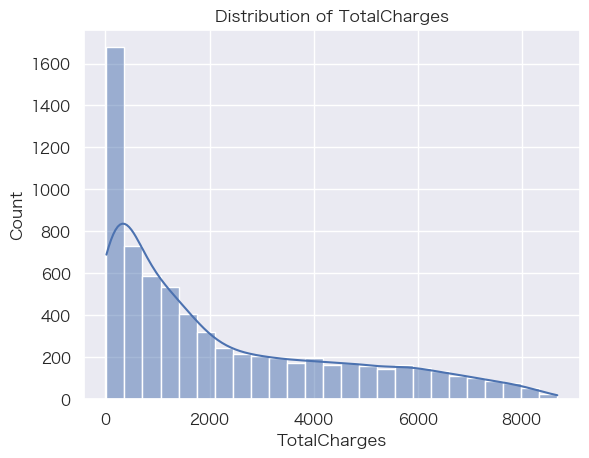

In [9]:
# TotalChargesの欠損値を補う前に、分布を確認
df['TotalCharges'].describe()

sns.histplot(df['TotalCharges'],kde=True,)
plt.title('Distribution of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Count')
plt.show()

In [10]:
# TotalChargesは偏った分布のため、中央値で補う
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [11]:
# 目的変数「Churn」の値をYesは1、Noは 0に転換
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

df['Churn'].unique()

array([0, 1])

# 6.データの分布を確認

Text(0.5, 1.0, '顧客流失状況')

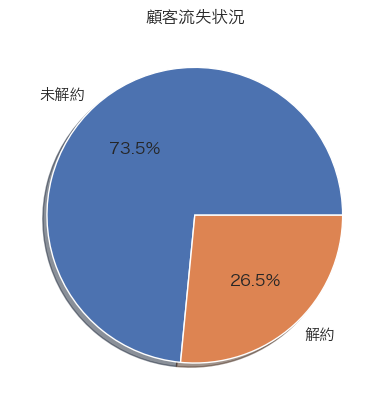

In [12]:
# 流失状況を確認
churn_counts = df['Churn'].value_counts()
labels = ['解約' if x==1 else '未解約' for x in churn_counts.index]

plt.pie(churn_counts,labels=labels,autopct='%1.1f%%',shadow=True)
plt.title('顧客流失状況')

- 解約顧客の比率は26.5％
- 継続顧客の比率は73.5％
- 明らかに，サンプルの分布が偏っている

# 7.feature selection 
データセットには多くの特徴量が含まれているため、各特徴量間の相関や、特徴量とターゲット変数（Churn）との相関を確認する必要がある。
これにより、目標変数に影響を与えない特徴量を除外して、モデルの精度向上や過学習の防止、計算効率の改善を図ることができる。
- 説明変数間の相関性と、説明変数と目的変数の相関性を確認
- 具体的な方法：correlation matrixを計算し、heatmapで可視化
- customerIDは一般的にハッシュ化されたため、あまり意味がなくて、直接に除外できる

### 説明変数間の相関性を確認

In [13]:
feature_cols = df.columns[1:21] # customerIDは一般的にハッシュ化されたため、あまり意味がなくて、直接に除外できる
features_df = df[feature_cols]

In [14]:
# カテゴリ特徴をencode
for col in features_df.select_dtypes('object'):
    features_df[col] = LabelEncoder().fit_transform(features_df[col])
    
display(features_df.head(2))

# correlation matrixを計算
features_corr = features_df.corr()
display(features_corr)

# 各特徴量の平均絶対相関を計算し、降順にソート（heatmapを書くために準備）
corr = features_corr.abs().mean().sort_values(ascending=False)
sorted_features = corr.index

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.006739,-0.000863,-0.015017,-0.012057,0.000549,-0.006825,-0.006421,-0.008743,0.000126,-0.011754,0.017352,-0.014569,-0.000002,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,-0.013632,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.102652,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,0.153130,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.318364,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,0.091015,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,0.063593,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,0.370876,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.825464,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,0.024105,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.113013,0.011942
MultipleLines,-0.006739,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,0.117327,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.452849,0.038037
InternetService,-0.000863,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,0.036138,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.175588,-0.047291
OnlineSecurity,-0.015017,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,0.185126,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.253935,-0.289309
OnlineBackup,-0.012057,-0.013632,0.153130,0.091015,0.370876,0.024105,0.117327,0.036138,0.185126,1.000000,0.187757,0.195748,0.147186,0.136722,0.280980,-0.013370,-0.124847,0.119777,0.375063,-0.195525


Text(0.5, 1.0, '変数間の相関性')

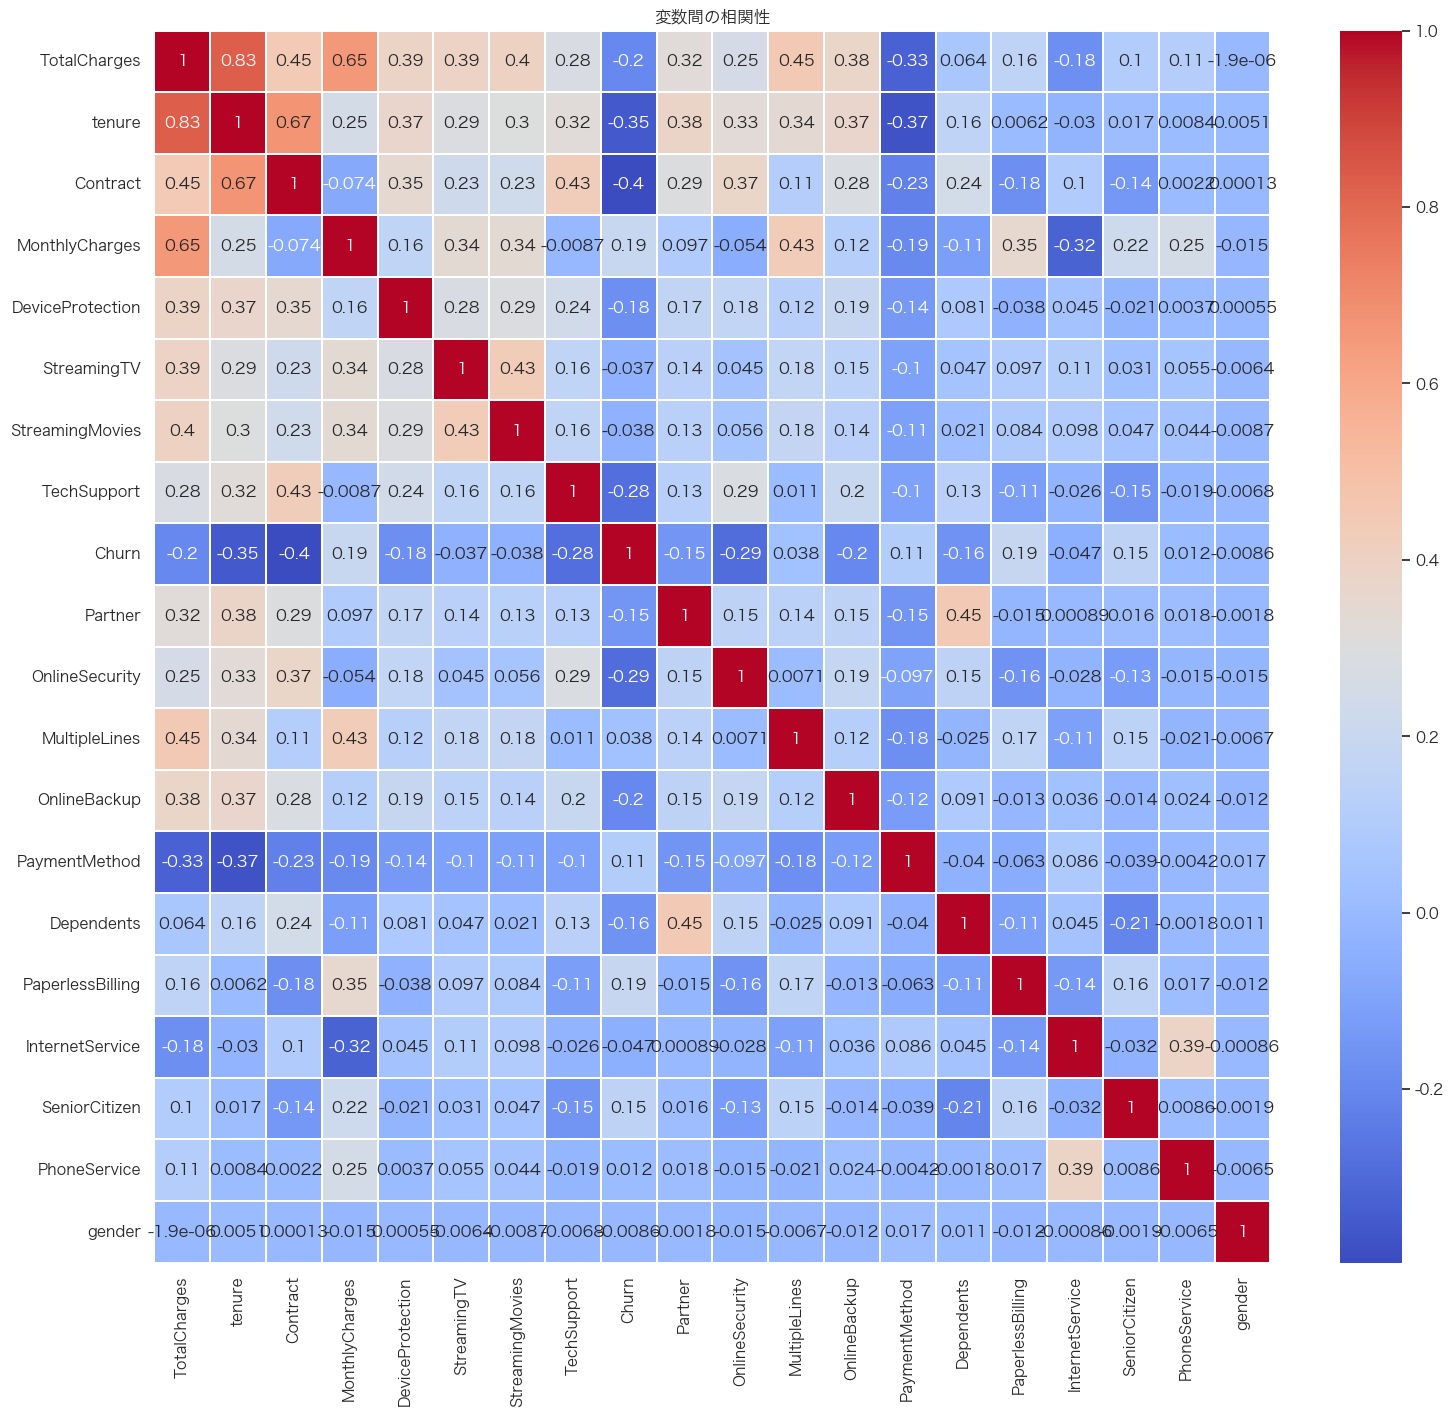

In [15]:
# heatmapで可視化
plt.figure(figsize=(18,16))
sns.heatmap(features_corr.loc[sorted_features,sorted_features],linewidths=0.2,annot=True,cmap='coolwarm')
plt.title('変数間の相関性')

統計学で、0.5以上は強い相関で0.3〜0.5程度の相関は中程度である。

- tenure と TotalCharges：0.825  
  <font color='red'>長期利用の顧客ほど総利用料金が高くなる傾向

- MonthlyCharges と TotalCharges：0.651  
  <font color='red'>月額料金が高いほど、総利用料金も高い

- Contract と tenure：0.672  
  <font color='red'>長期契約ほど契約期間が長くなる

- MultipleLines と TotalCharges：0.453  
  <font color='red'>複数回線を契約している顧客ほど総利用料金が高い

- StreamingTV　と　StreamingMoviesについて 
  - StreamingTV と MonthlyCharges：0.337  
  - StreamingMovies と MonthlyCharges：0.335  
  - StreamingTV と TotalCharges：0.392  
  - StreamingMovies と TotalCharges：0.398  
  <font color='red'>ストリーミングサービス利用の顧客は利用料金が高い


- OnlineBackup / DeviceProtection / TechSupport と TotalCharges  
  - OnlineBackup と TotalCharges：0.375  
  - DeviceProtection と TotalCharges：0.389  
  - TechSupport と TotalCharges：0.276  
  <font color='red'>OnlineBackup、DeviceProtection、TechSupport利用の顧客は総利用料金が高い

- Partner と Dependents  
  相関係数：0.453  
  <font color='red'>配偶者がいる顧客は扶養家族もいる傾向


### 説明変数と目的変数の相関性を確認

In [16]:
# onehotでencode（Churnも含まれる）
df_onehot = pd.get_dummies(df.iloc[:,1:21])
df_onehot['Churn'] = df['Churn']
df_onehot.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


Text(0.5, 1.0, '各説明変数と目的変数の相関性')

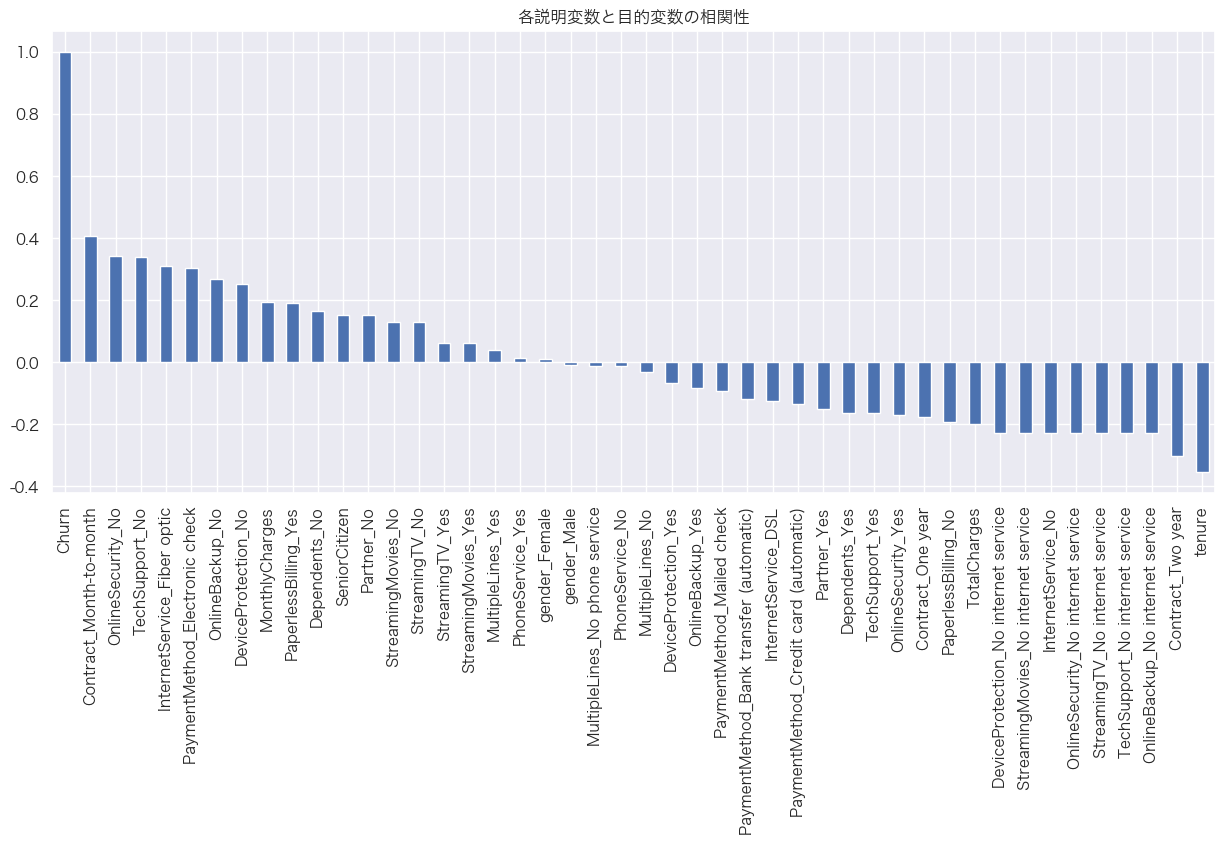

In [17]:
# Churnとの相関を計算して棒グラフで表示
plt.figure(figsize=(15,6))
df_onehot.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('各説明変数と目的変数の相関性')


- <font color='red'>genderと PhoneServiceは Churn との相関性がほぼ0であるため、これら2つの特徴量を除外できる。
- SeniorCitizen、Partner、Dependents、MultipleLines、InternetService、OnlineSecurity、OnlineBackup、DeviceProtection、TechSupport、StreamingTV、StreamingMovies、Contract、PaperlessBilling、PaymentMethod などの離散変数は比較的高い相関性がある。
これらの特徴量に基づいて、頻度比較を行い、どの特徴を持つ顧客が流失しやすいかを探す。

In [18]:
useful_var = [
    "SeniorCitizen", "Partner", "Dependents", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"
]

# 8. 統計分析

- 頻度比較を行い、どの特徴を持つ顧客が流失しやすいかを探す。

- しかし、このデータでは、解約顧客の比率は26.5％、継続顧客の比率は73.5％であり、サンプルの分布が偏っており、単純に頻度だけで顧客特性を探すのは問題がある。
    - 解決方法：クロス分析
      - 各特徴の比率を見ることで、流失しやすい顧客の特徴を探索

- しかし、各変数の比率を比較する前に、有意差検定を行うことが必要です。
    - これにより、観察された比率の差異が実際に存在するのか、データの偏りによる偶然の結果かを確認できます。
    - 例えば、「男性の顧客の解約率が女性より高い」と分かった場合、有意差検定によって、その差が実際の傾向か、データ分布による偶然のものかを判断できます。

- 具体的な方法：カイ二乗検定
- カイ二乗検定を用いる理由：複数の変数があり、かつ変数が離散型と連続型とも存在


In [19]:
# カイ二乗検定
def Chi_square(x):
    df1 = pd.crosstab(df['Churn'],df[x])
    li1 = list(df1.iloc[0,:])
    li2 = list(df1.iloc[1,:])
    chi_square_data=np.array([li1,li2])
    chi_square_obj = chi2_contingency(chi_square_data)
    if chi_square_obj[1]<0.05:
        print('Churn と {} のカイ二乗検定のp値は{:.2f}で、0.05未満です。{}のグループ間に有意差があり、✅クロス分析を行うことが可能です。'.format(x, chi_square_obj[1], x), '\n')
    else:
        print('Churn と {} のカイ二乗検定のp値は{:.2f}で、0.05以上です。{}のグループ間に有意差はなく、❌クロス分析は行えません。'.format(x, chi_square_obj[1], x), '\n')

print('useful_varのカイ二乗検定結果は以下の通りです:', '\n')
for var in useful_var:
    Chi_square(var)



useful_varのカイ二乗検定結果は以下の通りです: 

Churn と SeniorCitizen のカイ二乗検定のp値は0.00で、0.05未満です。SeniorCitizenのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と Partner のカイ二乗検定のp値は0.00で、0.05未満です。Partnerのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と Dependents のカイ二乗検定のp値は0.00で、0.05未満です。Dependentsのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と MultipleLines のカイ二乗検定のp値は0.00で、0.05未満です。MultipleLinesのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と InternetService のカイ二乗検定のp値は0.00で、0.05未満です。InternetServiceのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と OnlineSecurity のカイ二乗検定のp値は0.00で、0.05未満です。OnlineSecurityのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と OnlineBackup のカイ二乗検定のp値は0.00で、0.05未満です。OnlineBackupのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と DeviceProtection のカイ二乗検定のp値は0.00で、0.05未満です。DeviceProtectionのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と TechSupport のカイ二乗検定のp値は0.00で、0.05未満です。TechSupportのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と StreamingTV のカイ二乗検定のp値は0.00で、0.05未満です。StreamingTVのグループ間に有意差があり、✅クロス分析を行うことが可能です。 

Churn と StreamingMovies のカイ二乗検定のp値は

<font color='red'>カイ二乗検定の結果から、useful_varに含まれる特徴量はすべてグループ間に有意差があり、クロス分析を行うことが可能です。

### クロス分析

useful_varリストに含まれる特徴とChurnのクロス集計分析結果は以下の通りです： 

................Churn BY SeniorCitizen...............
SeniorCitizen         0         1
Churn                            
0              0.871279  0.128721
1              0.745318  0.254682 

................Churn BY Partner...............
Partner        No       Yes
Churn                      
0        0.471782  0.528218
1        0.642055  0.357945 

................Churn BY Dependents...............
Dependents        No       Yes
Churn                         
0           0.655199  0.344801
1           0.825575  0.174425 

................Churn BY MultipleLines...............
MultipleLines        No  No phone service       Yes
Churn                                              
0              0.491109          0.098956  0.409934
1              0.454254          0.090958  0.454789 

................Churn BY InternetService...............
InternetService       DSL  Fiber optic        No
Churn                                           
0  

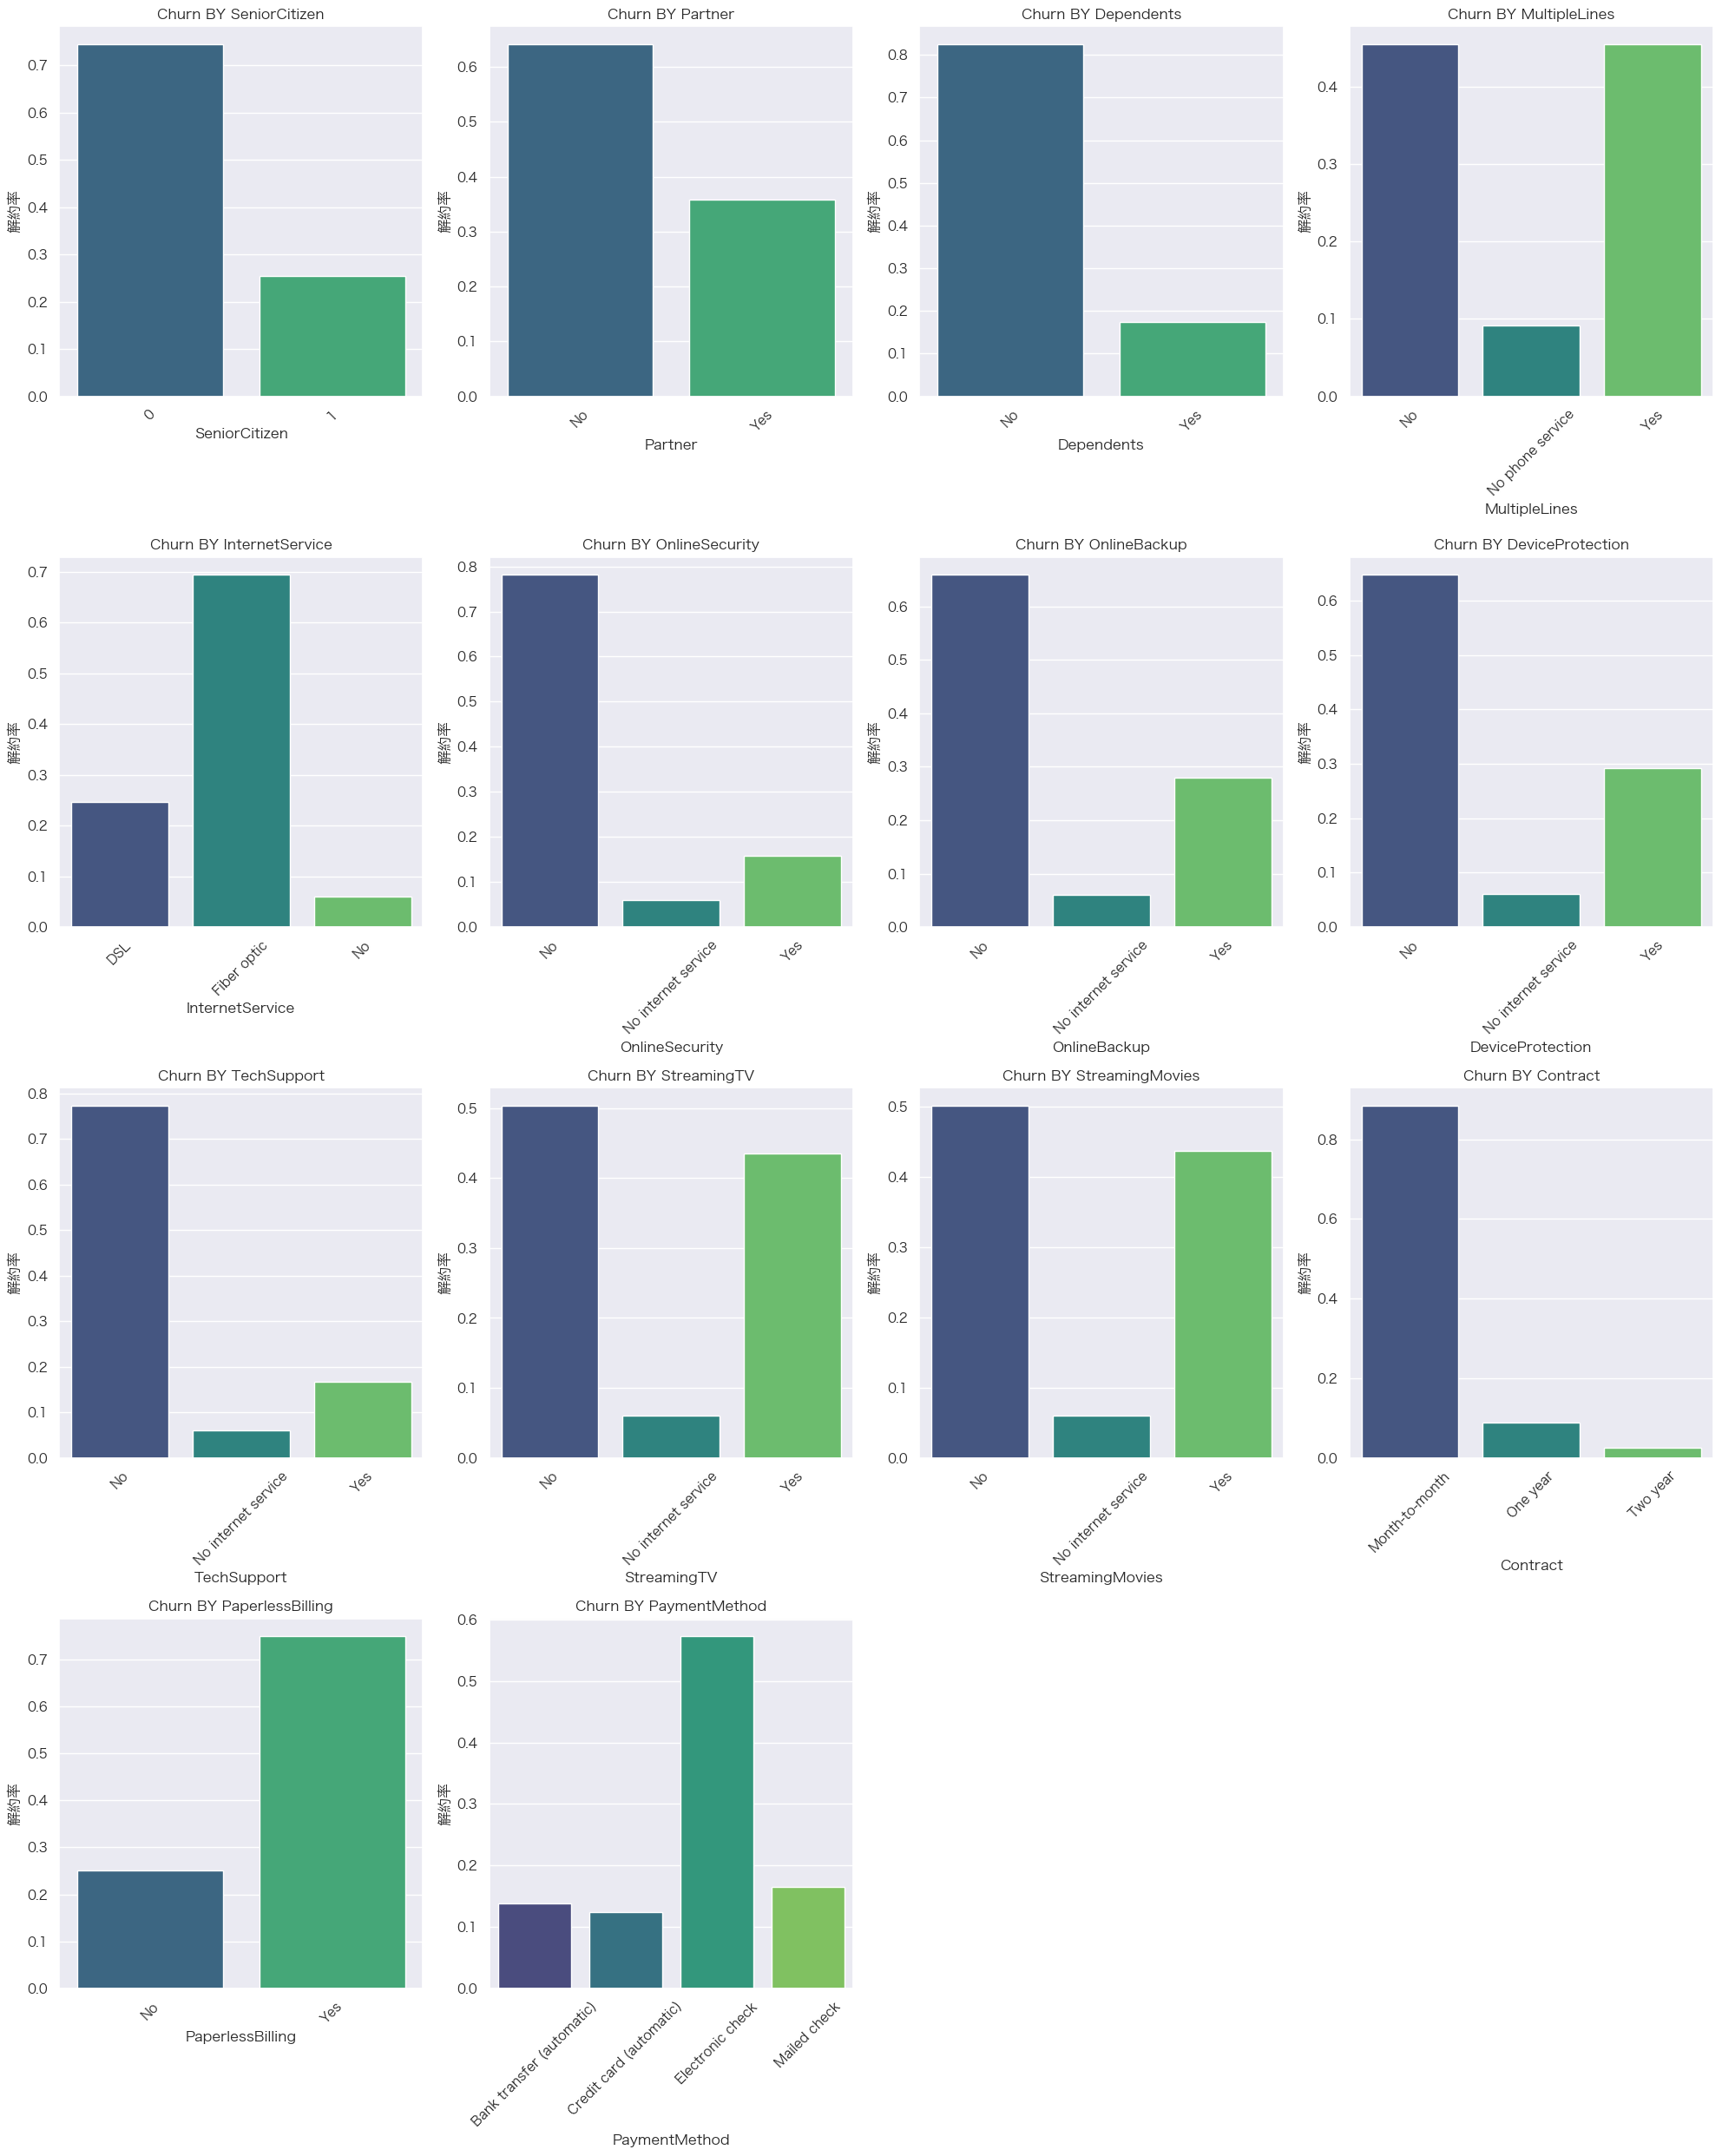

In [20]:
# クロス集計分析の結果を出力してグラフを作成

print('useful_varリストに含まれる特徴とChurnのクロス集計分析結果は以下の通りです：', '\n')

plt.figure(figsize=(20, 25))
a = 0

for i in useful_var:
    # クロス集計分析
    crosstab_result = pd.crosstab(df['Churn'], df[i], normalize='index')
    print('................Churn BY {}...............'.format(i))
    print(crosstab_result, '\n')
    
    # グラフの作成
    a += 1
    plt.subplot(4, 4, a)  # 総特徴量数に応じて行列数を調整
    sns.barplot(x=crosstab_result.columns, y=crosstab_result.iloc[1], palette='viridis')
    plt.title('Churn BY ' + i)
    plt.ylabel('解約率')
    plt.xlabel(i)
    plt.xticks(rotation=45)  # x軸ラベルを45度回転

plt.tight_layout()
plt.show()


以下の特徴を持つユーザーは解約しやすい傾向があります：

- SeniorCitizen：若年層
- Partner：独身
- Dependents：扶養家族なし
- InternetService：「Fiber optic（光ファイバーネットワーク）」を利用
- OnlineSecurity：「オンラインセキュリティサービス」を未契約
- OnlineBackup：「オンラインバックアップサービス」を未契約
- DeviceProtection：「デバイス保護サービス」を未契約
- TechSupport：「技術サポートサービス」を未契約
- Contract：「月単位（Month-to-Month）」の契約
- PaperlessBilling：ペーパーレス請求を利用
- PaymentMethod：デジタルで支払うユーザー

<font color='red'>MultipleLinesは解約に影響なし

# 9.モデリング
XGBoostを用いて各特徴量の重要性を評価
- 説明変数：useful_var（離散）＋　三つの連続型変数（MonthlyCharges、TotalCharges、tenure）
- 目的変数：Churn

In [21]:
ml_var = list(set(useful_var + ['MonthlyCharges','TotalCharges','tenure']) - set(['MultipleLines']))
X = df[ml_var]
X.head()

,SeniorCitizen,StreamingTV,MonthlyCharges,TotalCharges,InternetService,Dependents,DeviceProtection,PaperlessBilling,OnlineSecurity,tenure,TechSupport,PaymentMethod,Contract,OnlineBackup,StreamingMovies,Partner
0,0,No,29.85,29.85,DSL,No,No,Yes,No,1,No,Electronic check,Month-to-month,Yes,No,Yes
1,0,No,56.95,1889.50,DSL,No,Yes,No,Yes,34,No,Mailed check,One year,No,No,No
2,0,No,53.85,108.15,DSL,No,No,Yes,Yes,2,No,Mailed check,Month-to-month,Yes,No,No
3,0,No,42.30,1840.75,DSL,No,Yes,No,Yes,45,Yes,Bank transfer (automatic),One year,No,No,No
4,0,No,70.70,151.65,Fiber optic,No,No,Yes,No,2,No,Electronic check,Month-to-month,No,No,No


In [22]:
X.describe()

,SeniorCitizen,MonthlyCharges,TotalCharges,tenure
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,64.761692,2281.916928,32.371149
std,0.368612,30.090047,2265.270398,24.559481
min,0.000000,18.250000,18.800000,0.000000
25%,0.000000,35.500000,402.225000,9.000000
50%,0.000000,70.350000,1397.475000,29.000000
75%,0.000000,89.850000,3786.600000,55.000000
max,1.000000,118.750000,8684.800000,72.000000


In [23]:
# 特徴標準化（MonthlyCharges,TotalCharges,tenure）
scaler = StandardScaler(copy=False)
scaler.fit_transform(X[['MonthlyCharges','TotalCharges','tenure']])  
X[['MonthlyCharges','TotalCharges','tenure']]=scaler.transform(X[['MonthlyCharges','TotalCharges','tenure']])  

X[['MonthlyCharges','TotalCharges','tenure']].head() 

,MonthlyCharges,TotalCharges,tenure
0,-1.160323,-0.994242,-1.277445
1,-0.259629,-0.173244,0.066327
2,-0.362660,-0.959674,-1.236724
3,-0.746535,-0.194766,0.514251
4,0.197365,-0.940470,-1.236724


In [24]:
# 離散特徴をエンコード
df_object = X.select_dtypes(['object'])

for col in df_object.columns:
    X[col] = LabelEncoder().fit_transform(X[col])

X.head()

,SeniorCitizen,StreamingTV,MonthlyCharges,TotalCharges,InternetService,Dependents,DeviceProtection,PaperlessBilling,OnlineSecurity,tenure,TechSupport,PaymentMethod,Contract,OnlineBackup,StreamingMovies,Partner
0,0,0,-1.160323,-0.994242,0,0,0,1,0,-1.277445,0,2,0,2,0,1
1,0,0,-0.259629,-0.173244,0,0,2,0,2,0.066327,0,3,1,0,0,0
2,0,0,-0.362660,-0.959674,0,0,0,1,2,-1.236724,0,3,0,2,0,0
3,0,0,-0.746535,-0.194766,0,0,2,0,2,0.514251,2,0,1,0,0,0
4,0,0,0.197365,-0.940470,1,0,0,1,0,-1.236724,0,2,0,0,0,0


In [25]:
# サンプルの不均衡を処理（解約顧客の比率は26.5％、継続顧客の比率は73.5％）
y = df['Churn'].values
print('サンプリング前のデータ特徴量:', X.shape)
print('サンプリング前のデータラベル:', y.shape)

# Oversampling
model_smote = SMOTE()
X, y = model_smote.fit_resample(X, y)
X = pd.DataFrame(X, columns=X.columns)

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)


# Oversampling後、ラベルの分布を確認
print('Oversampling後のラベル分布：')
print(pd.Series(y).value_counts())  # Pandas Seriesに変換してvalue_countsを使用
print('-'*30)

# 訓練データのラベル分布
print('訓練データのラベル分布：')
print(pd.Series(y_train).value_counts())
print('-'*30)


# テストデータのラベル分布
print('テストデータのラベル分布：')
print(pd.Series(y_test).value_counts())
print('-'*30)

サンプリング前のデータ特徴量: (7043, 16)
サンプリング前のデータラベル: (7043,)
Oversampling後のラベル分布：
0    5174
1    5174
Name: count, dtype: int64
------------------------------
訓練データのラベル分布：
0    3627
1    3616
Name: count, dtype: int64
------------------------------
テストデータのラベル分布：
1    1558
0    1547
Name: count, dtype: int64
------------------------------


In [26]:
# モデリング

# XGBoostモデルの定義
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 学習
xgb_model.fit(X_train, y_train)

# 予測
y_pred = xgb_model.predict(X_test)

# モデルの評価
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("Recall:", recall)
print("Precision:", precision)
print("F1-score:", f1score)


Recall: 0.8645699614890886
Precision: 0.7714776632302406
F1-score: 0.8153753026634383


,feature,feature_importance
12,Contract,0.431469
8,OnlineSecurity,0.139400
10,TechSupport,0.093434
9,tenure,0.038286
5,Dependents,0.037619
4,InternetService,0.034757
14,StreamingMovies,0.029879
2,MonthlyCharges,0.028846
1,StreamingTV,0.027622
11,PaymentMethod,0.026111


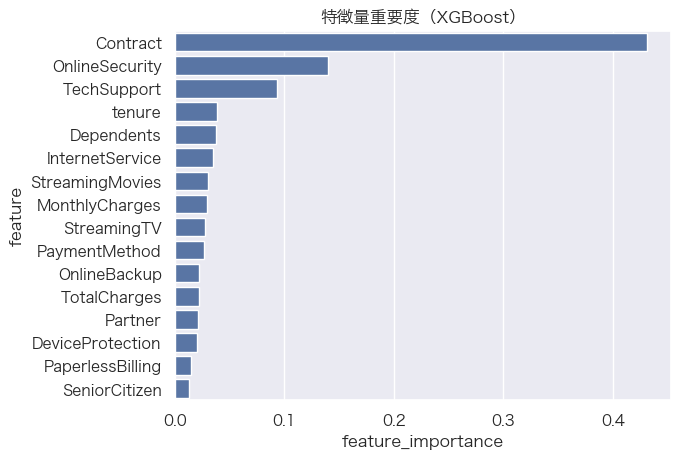

In [27]:
# 各特徴の重要性を出力して、可視化
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,               
    'feature_importance': xgb_model.feature_importances_  
}).sort_values('feature_importance', ascending=False)

display(xgb_importance)

# 可視化
plt.title('特徴量重要度（XGBoost）')
sns.barplot(x='feature_importance', y='feature', data=xgb_importance)
plt.show()


XGBoostによる特徴量重要度を確認したところ、以下の傾向が見られました。

- Contract（契約タイプ）：最も重要で、顧客の解約予測に大きく影響。
- OnlineSecurity：次に重要。
- TecSupport・InternetService・Dependents：中程度の影響。
- その他の変数（OnlineBackup、PaymentMethod、Partner、StreamingMovies、StreamingTV、SeniorCitizen、PaperlessBilling、DeviceProtection,tenure,MonthlyCharges,TotalCharges）：影響は比較的小さい。

**総合まとめ**
- 解約予測に最も重要なのはContract、OnlineSecurity。
- <font color='red'>連続変数は具体的な数値情報を提供できるため、施策を提案する際の優先度としては、まず**契約タイプ**や**オンラインセキュリティ**に注目し、次に**支払額**や**契約期間**を分析するのが効果的です。



Text(0.5, 1.0, '契約タイプにより解約の状況')

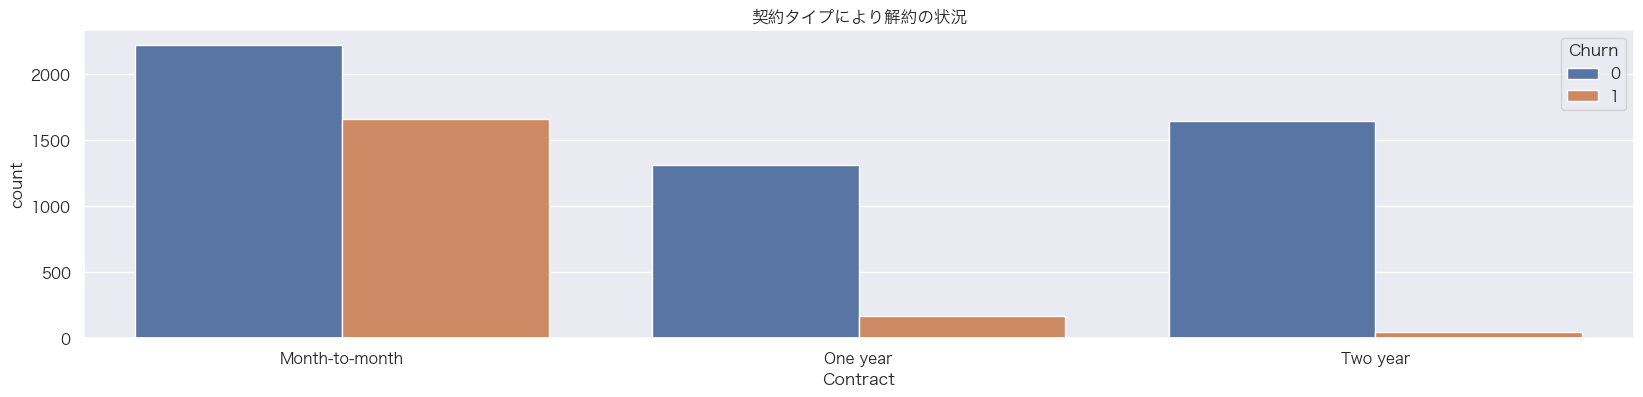

In [28]:
# 重要度が一番高い特徴：Contract
plt.figure(figsize=(20,4))
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title('契約タイプにより解約の状況')

- 図から、Month-to-month契約の顧客は解約しやすい傾向が見られ、特に注目して対応する必要があります。

Text(0.5, 1.0, 'OnlineSecurityにより解約の状況')

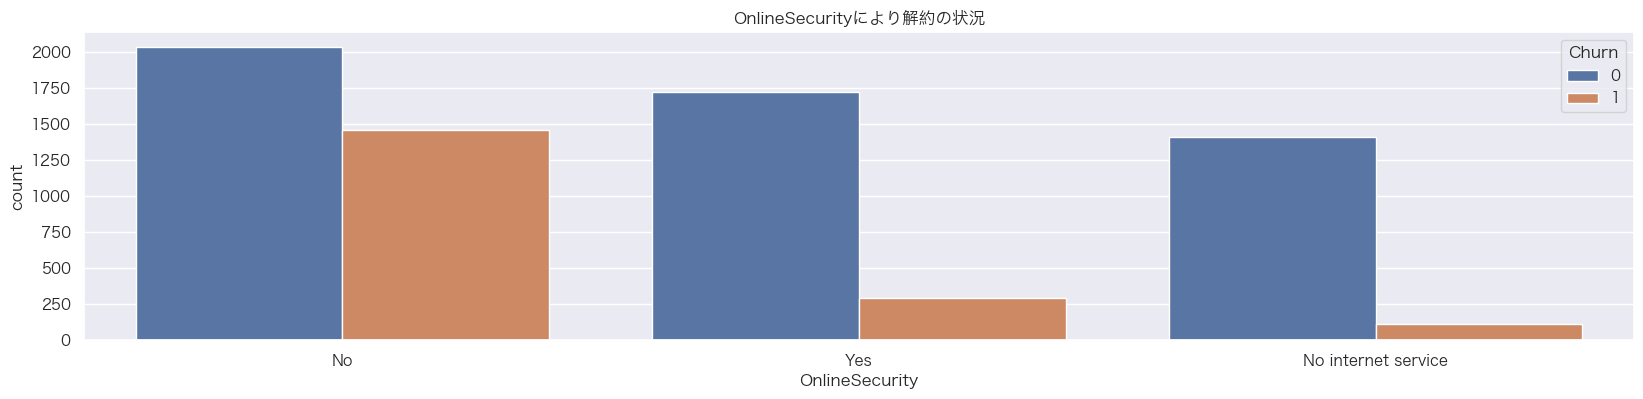

In [29]:
# 重要度が二番目高い特徴：OnlineSecurity
plt.figure(figsize=(20,4))
sns.countplot(x='OnlineSecurity',hue='Churn',data=df)
plt.title('OnlineSecurityにより解約の状況')

- 図から、OnlineSecurityを契約しない顧客は解約しやすい傾向が見られ、特に注目して対応する必要があります。

Text(0.5, 1.0, 'tenure(契約期間)により解約の状況')

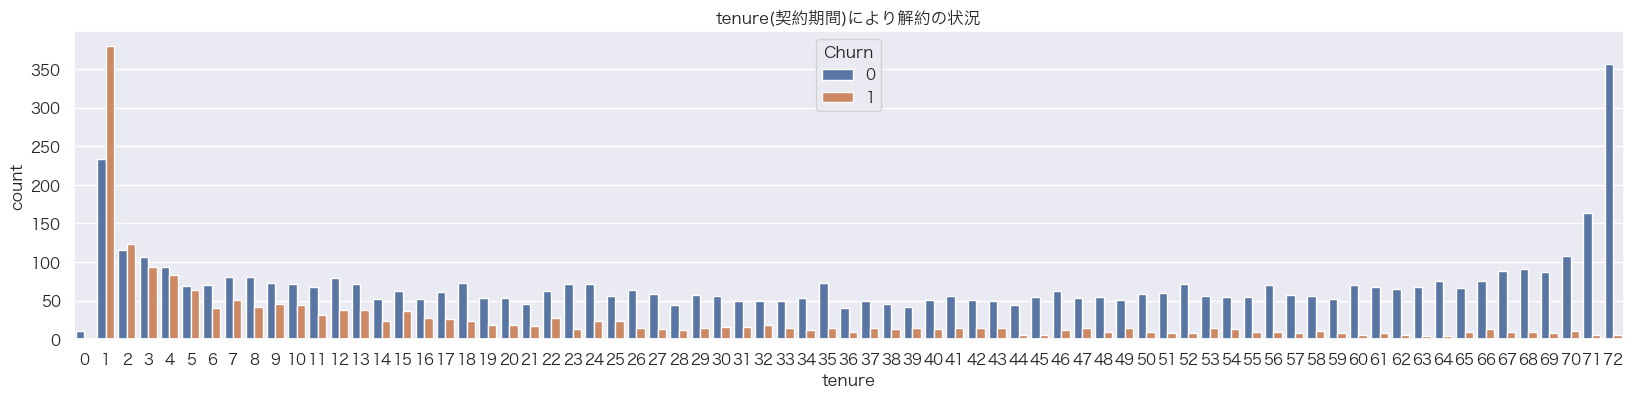

In [30]:
plt.figure(figsize=(20,4))
sns.countplot(x='tenure',hue='Churn',data=df)
plt.title('tenure(契約期間)により解約の状況')

- 図から、契約から最初の5か月間は顧客が最も流失しやすいことが分かり、特に注目して対応する必要があります。

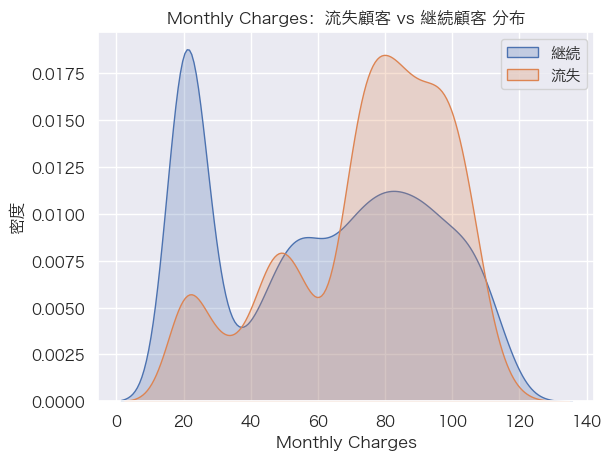

In [31]:
# MonthlyChargesの分布
sns.kdeplot(df[df['Churn']==0]['MonthlyCharges'], label='継続', fill=True)
sns.kdeplot(df[df['Churn']==1]['MonthlyCharges'], label='流失', fill=True)

plt.xlabel('Monthly Charges')
plt.ylabel('密度')
plt.title('Monthly Charges：流失顧客 vs 継続顧客 分布')
plt.legend()
plt.show()


- 月額利用料金が60〜110ドルの顧客は流失しやすい。

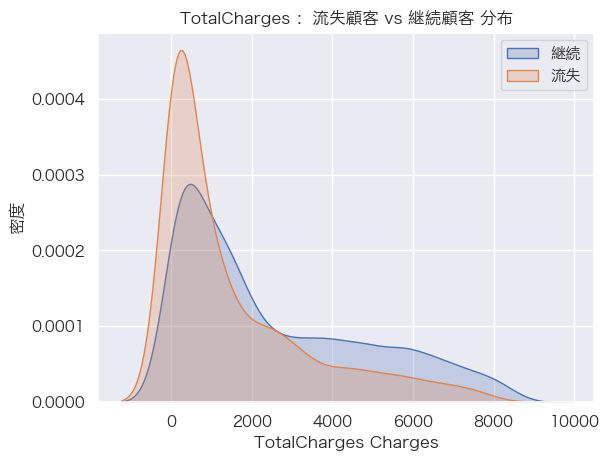

In [32]:
# TotalChargesの分布
sns.kdeplot(df[df['Churn']==0]['TotalCharges'], label='継続', fill=True)
sns.kdeplot(df[df['Churn']==1]['TotalCharges'], label='流失', fill=True)

plt.xlabel('TotalCharges Charges')
plt.ylabel('密度')
plt.title('TotalCharges ：流失顧客 vs 継続顧客 分布')
plt.legend()
plt.show()

- 総利用料金が0-2000ドルの顧客は流失しやすい。

# 10.分析結果まとめと施策提案

## 結果まとめ
統計分析とXGBoostによる特徴量重要度の出力結果を総合すると、解約（流失）しやすい顧客の特徴は以下の通りです（重要度の高い順）：  

<font color='red'>1.Contract：月単位契約 <br>
<font color='red'>2. OnlineSecurity：ネットワークセキュリティサービス未契約 <br>
<font color='red'>3. TechSupport：技術サポートサービス未契約  <br>
<font color='red'>4. tenure：契約開始後5か月以内の顧客   <br>
<font color='red'>5. Dependents：扶養家族なし  <br>

6. InternetService：契約開始後5か月以内の顧客
7. StreamingMovies：動画ストリーミング未契約 
8. MonthlyCharges：月額利用料60〜110ドルの顧客
9. StreamingTV：TVストリーミング未契約
10. PaymentMethod：電子チェック（Electronic Check）で支払い
11. OnlineBackup：オンラインバックアップ未契約
12. TotalCharges：総利用料金2,000ドル未満の顧客
13. Partner：未婚・独身
14. DeviceProtection：デバイス保護サービス未契約
15. PaperlessBilling：デジタル決済  
16. SeniorCitizen：若年層


## 解約を防ぐための提案

顧客を維持するには、主に2つの方向から考えれます
- ユーザーのサンクコストを増やす
- ユーザーの利用習慣を育てる

具体的には：<br>

<font color='red'>**施策1：段階的に利用料金を還元する**
- **現象**：月契約の若年層は解約しやすい
- **仮説**：これらの顧客は、価格に敏感で、学生や社会人1～2年目などが多いと想定される
- **提案**：チャージ時に段階的に利用料金を還元することで、継続利用を促すことができる。
  - 例：50ドルをチャージすると50ドルを還元するが、一度に還元せず、10か月に分けて還元する。すなわち、月額利用料が50ドルの場合、実質的には10回の「チャージ50ドル＋5ドル割引」の施策となる。
- **ロジック**：ユーザーのサンクコストを増やし、解約を防ぐ

<font color='red'>**施策2：TechSupport、OnlineSecurity、InternetService などのサービスを1か月間無料体験として提供する**
- **現象**：TechSupport、OnlineSecurity、InternetServiceを契約しないユーザーは流失しやすい
- **仮説**：光ファイバー、技術サポート、ネットワークセキュリティなどのサービスを利用することで、解約時に面倒を感じさせ、解約を防ぐ
- **提案**：以下のサービスを1ヶ月間の無料体験を提供し、サービスの利用を促進
  - 光ファイバー
  - 技術サポートサービス
  - ネットワークセキュリティサービス
- **ロジック**：付加価値サービスによりユーザーのサンクコストを増やし、解約を防ぐ



<font color='red'>**施策3：デジタル決済特典**
- **現象**：「デジタル決済」を使っている人ほど解約しやすい
- **仮説**：価格に敏感で、電子請求書で支出を管理している可能性がある
- **提案**：電子請求書を“単なる請求手段”ではなく、特典付きサービスにする
  - 例：コンビニチェーンと連携し、商品割引クーポンを毎月の請求書と一緒に送付
    - 例文：「先月のご利用金額はXX円でした。LV1/LV2/LV3などの会員特典を解放しました！XXクーポンです！」
- **ロジック**：ユーザーのサンクコストを増やし、解約を防ぐ

<font color='red'>**施策4：「独身ユーザー」専用特典**
- **現象**：独身ユーザーは流失しやすい
- **仮説**：独身者は社交的な動機が薄く、ゲームやSNSなどを使ったエンターテインメントを楽しむ傾向がある  
- **提案**：通信プランに、ゲームやSNS利用などの特典を追加する
   - 例えば、ゲーム内アイテムと交換できるコードがもらえる
- **ロジック**：ユーザーの利用習慣を育て、解約を防ぐ



